# Phase 4 — Mempool Heatmap Dashboard
## Bitcoin On-Chain Analytics — Binance Era (2017-2026)

**Objective:** Visualize fee congestion patterns by hour and weekday using on-chain confirmed fees as a mempool proxy.

- Heatmap: Hour of Day vs Day of Week
- Color intensity: Average fees (BTC) per time slot
- Subplots: Bull vs Bear market regimes
- Static matplotlib visualizations

In [1]:
import os
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

os.makedirs('images', exist_ok=True)
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Connect to ClickHouse
client = clickhouse_connect.get_client(host='localhost', port=8123)
print('Connected to ClickHouse')

# Query: hourly aggregation directly in ClickHouse (NO Python groupby on large data)
print('Running query (hourly aggregation in ClickHouse)...')
df_blocks = client.query_df('''
    SELECT 
        toDateTime(time) AS block_time,
        fees_sats / 100000000.0 AS fees_btc,
        nTx
    FROM block_metrics
    WHERE toDateTime(time) >= '2017-07-14'
    ORDER BY block_time
''')

# Force tz-naive
df_blocks['block_time'] = pd.to_datetime(df_blocks['block_time']).dt.tz_localize(None)

# Extract time features
df_blocks['hour'] = df_blocks['block_time'].dt.hour
df_blocks['weekday'] = df_blocks['block_time'].dt.dayofweek
df_blocks['date'] = df_blocks['block_time'].dt.date

print(f'Blocks loaded: {len(df_blocks):,}')
print(f'Period: {df_blocks["block_time"].min()} to {df_blocks["block_time"].max()}')
df_blocks.head()

Connected to ClickHouse
Running query (hourly aggregation in ClickHouse)...
Blocks loaded: 472,563
Period: 2017-07-14 00:09:48 to 2026-05-05 14:22:51


,block_time,fees_btc,nTx,hour,weekday,date
0,2017-07-14 00:09:48,2.181809,2320,0,4,2017-07-14
1,2017-07-14 00:28:17,1.701480,2325,0,4,2017-07-14
2,2017-07-14 00:49:27,2.015362,2145,0,4,2017-07-14
3,2017-07-14 00:51:50,0.601285,2083,0,4,2017-07-14
4,2017-07-14 01:02:28,1.496814,1863,1,4,2017-07-14


In [3]:
# Define market regimes using date
def classify_regime(d):
    d = pd.Timestamp(d)
    if d <= pd.Timestamp('2018-12-31'):
        return '2017-2018 Bull & Bear'
    elif d <= pd.Timestamp('2021-12-31'):
        return '2019-2021 Cycle'
    elif d <= pd.Timestamp('2023-12-31'):
        return '2022-2023 Bear'
    else:
        return '2024-2026 Bull'

df_blocks['regime'] = df_blocks['date'].apply(classify_regime)

# Weekday names
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hour_labels = [f'{h:02d}:00' for h in range(24)]

print('Regime distribution:')
print(df_blocks['regime'].value_counts())

Regime distribution:
regime
2019-2021 Cycle          160149
2024-2026 Bull           124490
2022-2023 Bear           107187
2017-2018 Bull & Bear     80737
Name: count, dtype: int64


Saved: images/mempool_heatmap_full.png


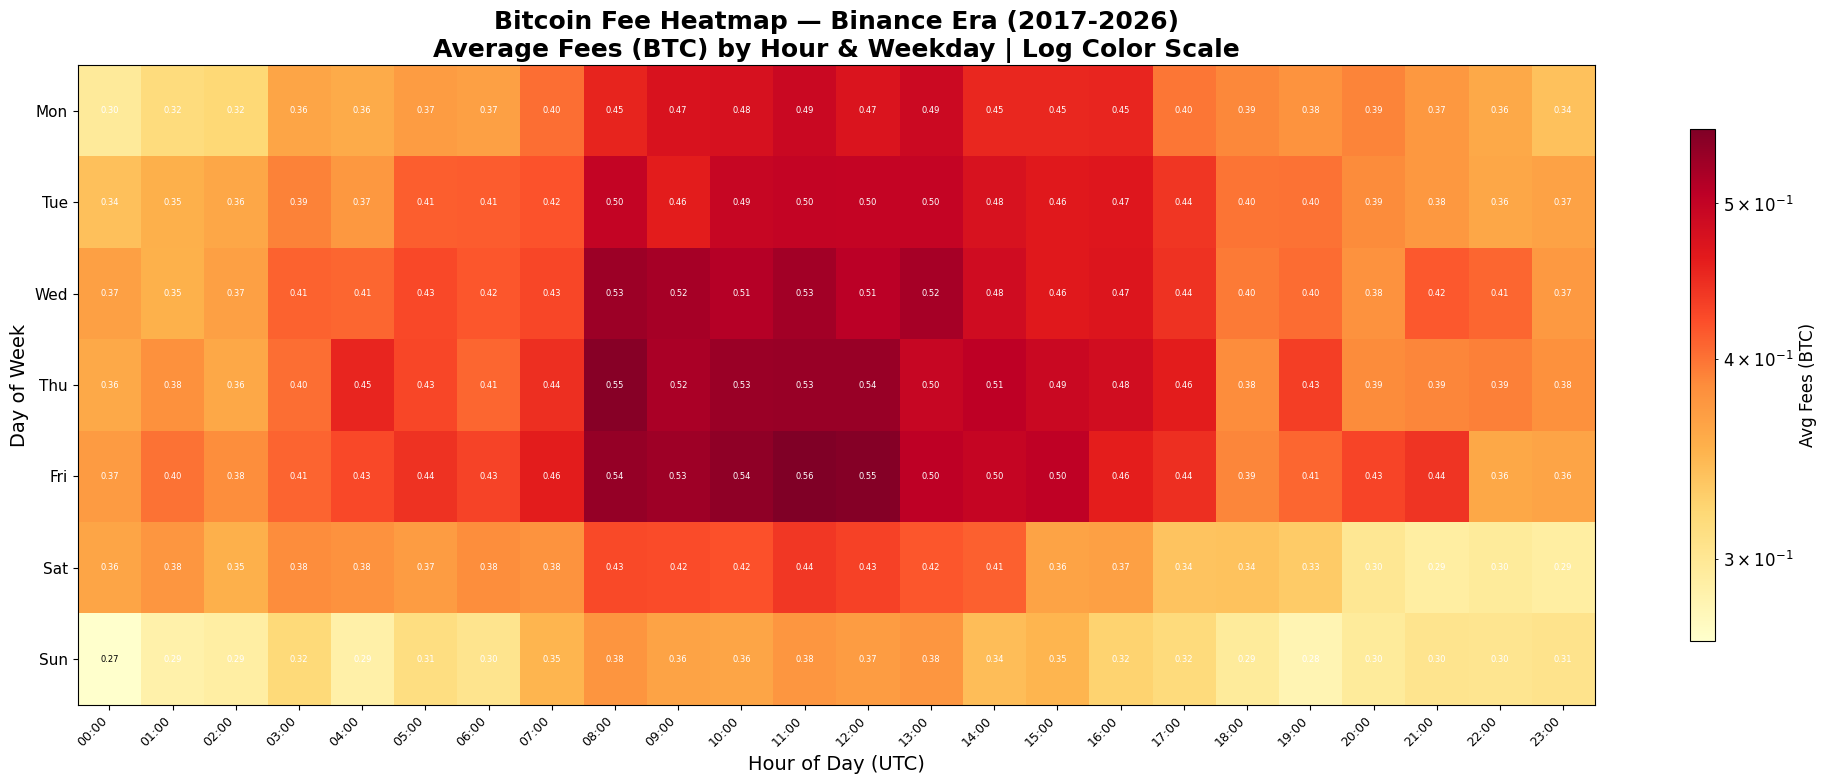

In [4]:
# Build heatmap: Full period
def build_heatmap(df, regime_name=None):
    if regime_name:
        df = df[df['regime'] == regime_name]
    
    heatmap_data = df.groupby(['weekday', 'hour'])['fees_btc'].mean().unstack()
    heatmap_data = heatmap_data.reindex(index=range(7), columns=range(24))
    return heatmap_data

# Full period heatmap
heatmap_all = build_heatmap(df_blocks)

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(heatmap_all.values, cmap='YlOrRd', aspect='auto', norm=mcolors.LogNorm())

ax.set_xticks(range(24))
ax.set_xticklabels(hour_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(weekday_names, fontsize=11)
ax.set_xlabel('Hour of Day (UTC)', fontsize=14)
ax.set_ylabel('Day of Week', fontsize=14)
ax.set_title('Bitcoin Fee Heatmap — Binance Era (2017-2026)\nAverage Fees (BTC) by Hour & Weekday | Log Color Scale',
             fontsize=18, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Avg Fees (BTC)', shrink=0.8)
cbar.ax.yaxis.set_label_text('Avg Fees (BTC)', fontsize=12)

# Annotate cells
for i in range(7):
    for j in range(24):
        val = heatmap_all.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='black' if val < heatmap_all.values.max() * 0.5 else 'white')

plt.tight_layout()
plt.savefig('images/mempool_heatmap_full.png', dpi=300, bbox_inches='tight')
print('Saved: images/mempool_heatmap_full.png')
plt.show()

Saved: images/mempool_heatmap_regimes.png


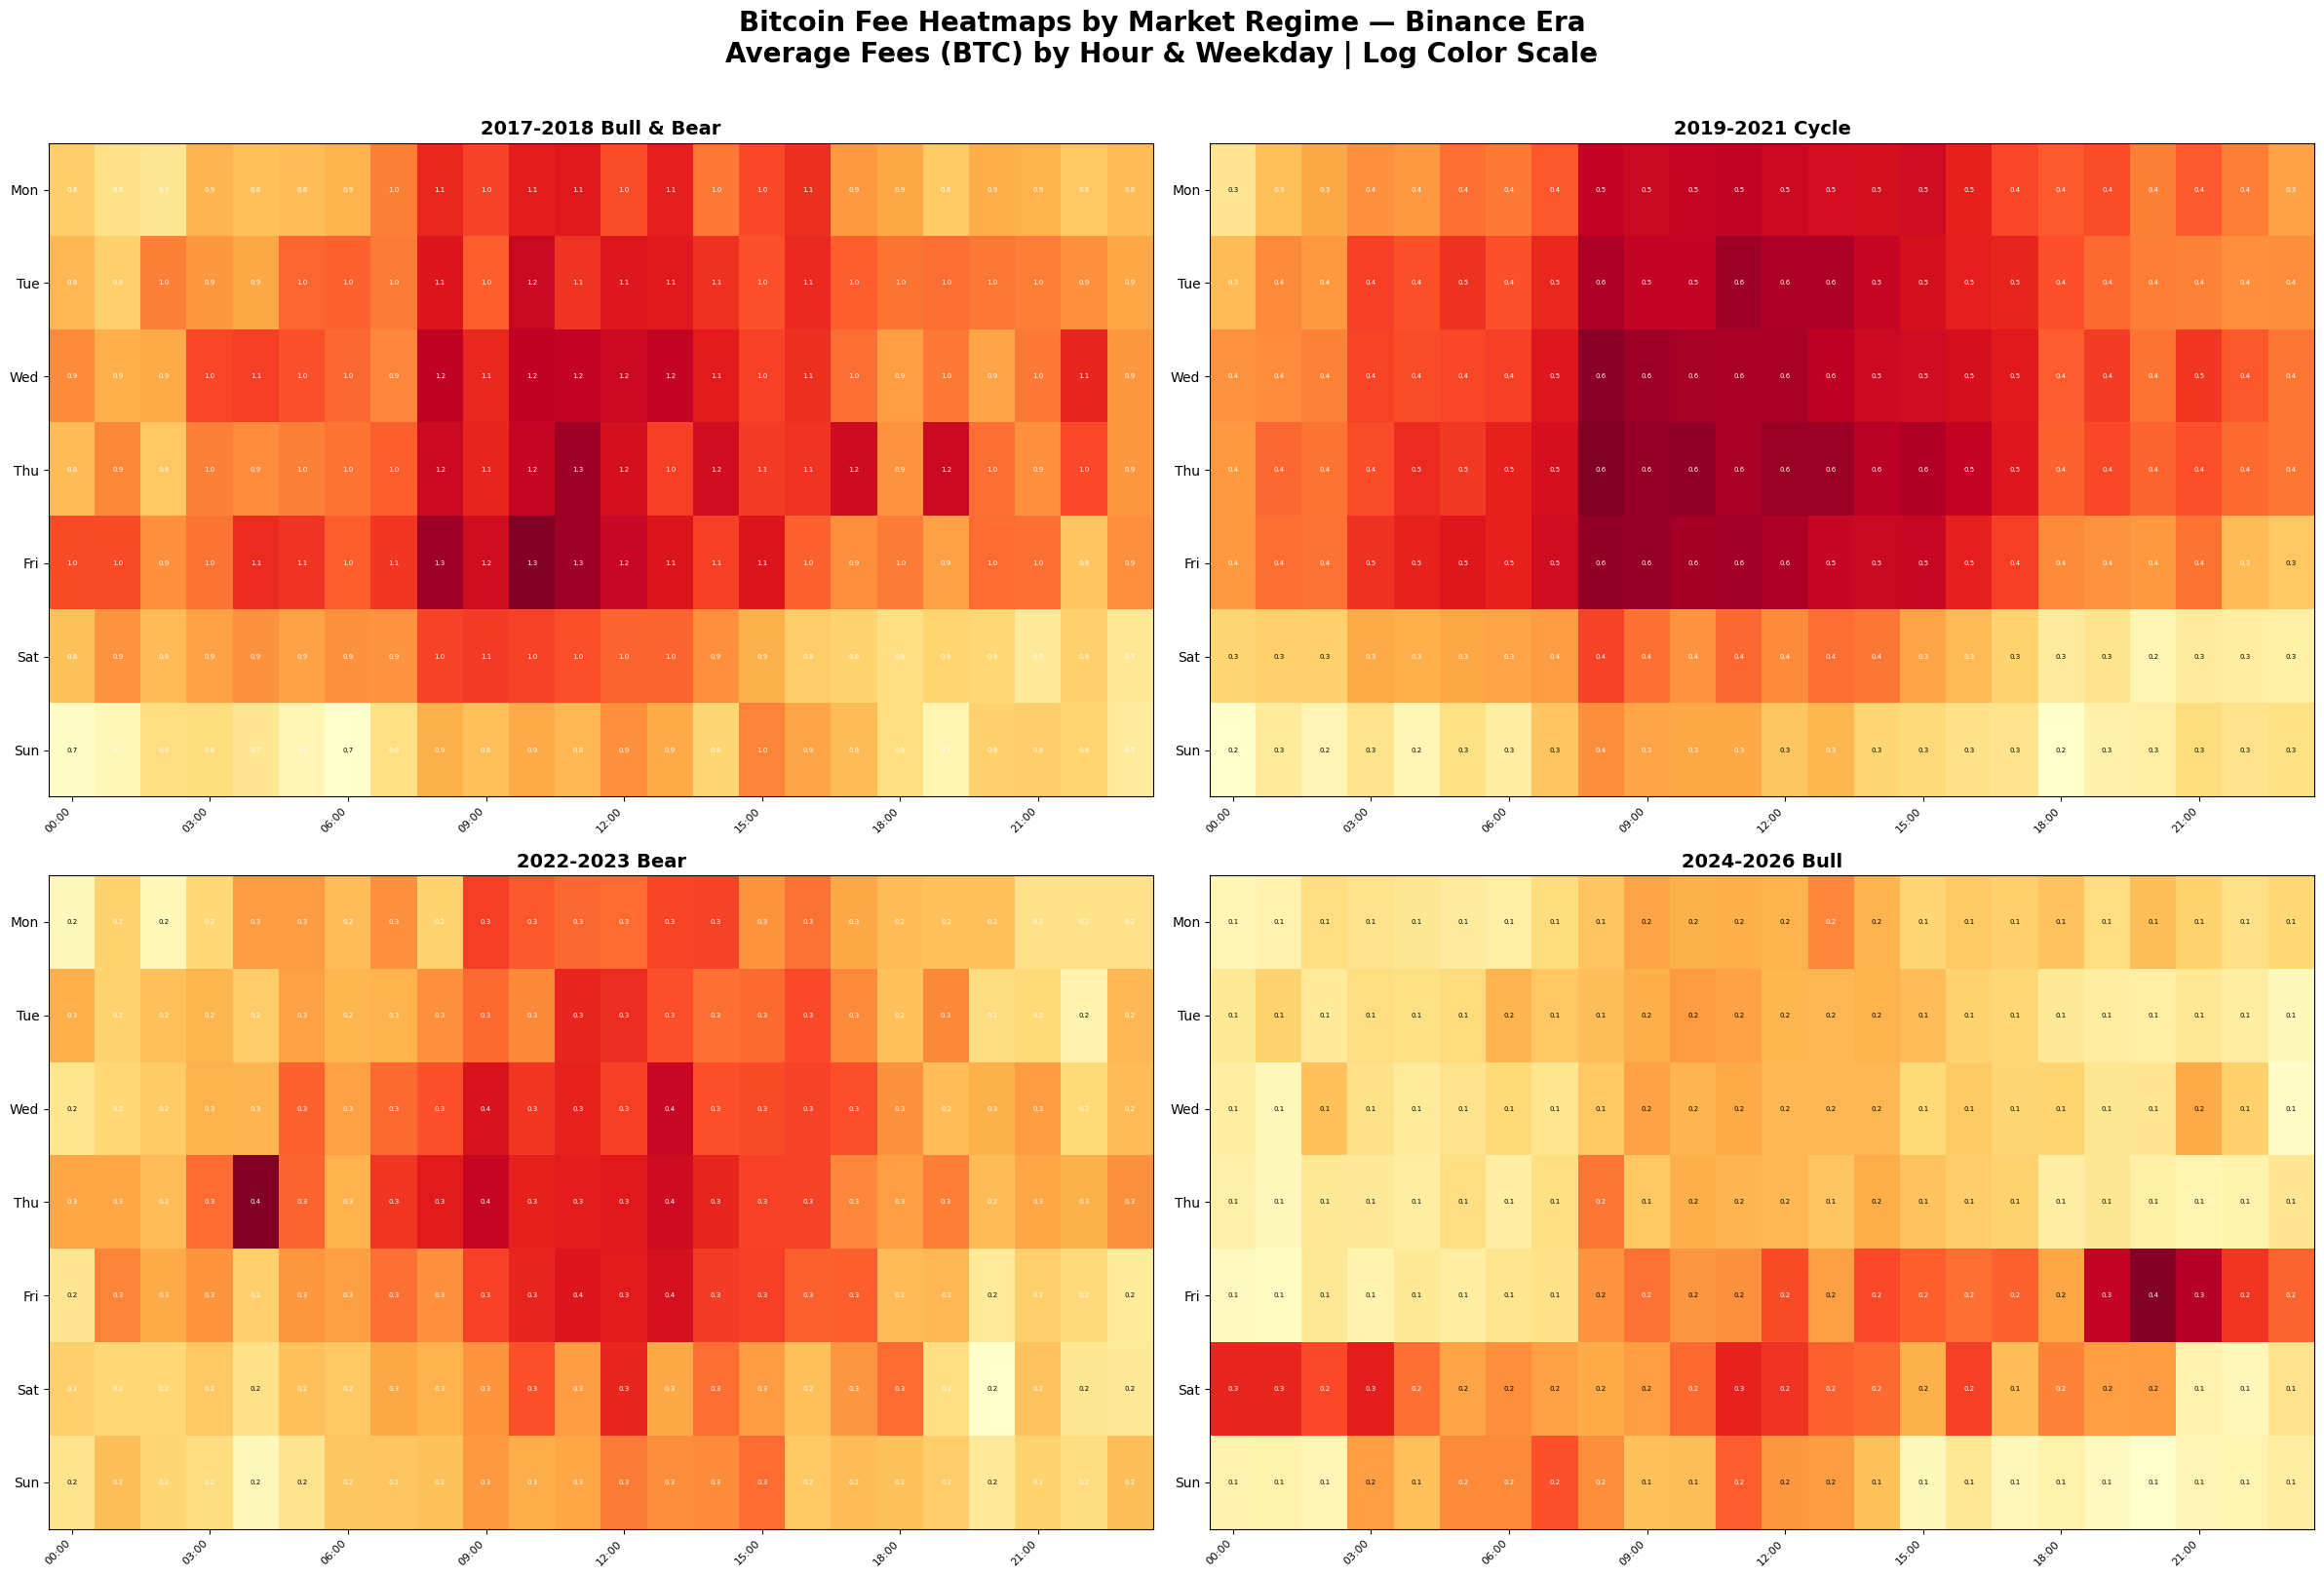

In [5]:
# Subplots by market regime
regimes = ['2017-2018 Bull & Bear', '2019-2021 Cycle', '2022-2023 Bear', '2024-2026 Bull']
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

for idx, (regime, ax) in enumerate(zip(regimes, axes.flat)):
    heatmap = build_heatmap(df_blocks, regime)
    
    im = ax.imshow(heatmap.values, cmap='YlOrRd', aspect='auto', norm=mcolors.LogNorm())
    
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(7))
    ax.set_yticklabels(weekday_names, fontsize=10)
    ax.set_title(regime, fontsize=14, fontweight='bold')
    
    for i in range(7):
        for j in range(24):
            val = heatmap.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=5,
                        color='black' if val < heatmap.values.max() * 0.5 else 'white')

fig.suptitle('Bitcoin Fee Heatmaps by Market Regime — Binance Era\nAverage Fees (BTC) by Hour & Weekday | Log Color Scale',
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/mempool_heatmap_regimes.png', dpi=300, bbox_inches='tight')
print('Saved: images/mempool_heatmap_regimes.png')
plt.show()

In [6]:
# Peak congestion analysis: Top 5 hottest hours
hourly_stats = df_blocks.groupby(['weekday', 'hour']).agg(
    avg_fees=('fees_btc', 'mean'),
    total_blocks=('fees_btc', 'count'),
    max_fees=('fees_btc', 'max'),
    avg_tx=('nTx', 'mean')
).reset_index()

hourly_stats['weekday_name'] = hourly_stats['weekday'].map(lambda x: weekday_names[x])
hourly_stats['hour_label'] = hourly_stats['hour'].map(lambda x: f'{x:02d}:00')
hourly_stats['slot'] = hourly_stats['weekday_name'] + ' ' + hourly_stats['hour_label']

top_hours = hourly_stats.nlargest(10, 'avg_fees')
print('Top 10 Most Congested Time Slots:')
top_hours[['slot', 'avg_fees', 'max_fees', 'total_blocks', 'avg_tx']].round(2)

Top 10 Most Congested Time Slots:


,slot,avg_fees,max_fees,total_blocks,avg_tx
107,Fri 11:00,0.56,11.05,2911,2566.54
108,Fri 12:00,0.55,12.22,2771,2608.84
80,Thu 08:00,0.55,15.55,2743,2470.62
106,Fri 10:00,0.54,14.82,2813,2686.76
104,Fri 08:00,0.54,12.70,2772,2391.16
84,Thu 12:00,0.54,9.76,2814,2618.20
83,Thu 11:00,0.53,10.46,2823,2588.08
82,Thu 10:00,0.53,10.52,2702,2636.15
56,Wed 08:00,0.53,9.05,2659,2485.10
105,Fri 09:00,0.53,11.22,2751,2502.36


---
## Phase 4 Conclusions — Mempool Heatmap

### Data Coverage
472,563 blocks analyzed across 4 market regimes from July 14, 2017 to May 2026.

### Regime Distribution
- 2017-2018 Bull & Bear: 80,737 blocks (17.1%)
- 2019-2021 Cycle: 160,149 blocks (33.9%)
- 2022-2023 Bear: 107,187 blocks (22.7%)
- 2024-2026 Bull: 124,490 blocks (26.3%)

### Top 10 Most Congested Time Slots (Average Fees)

| # | Slot | Avg Fees (BTC) | Max Fees (BTC) | Blocks | Avg Tx |
|---|------|---------------|---------------|--------|--------|
| 1 | Fri 11:00 UTC | 0.56 | 11.05 | 2,911 | 2,567 |
| 2 | Fri 12:00 UTC | 0.55 | 12.22 | 2,771 | 2,609 |
| 3 | Thu 08:00 UTC | 0.55 | 15.55 | 2,743 | 2,471 |
| 4 | Fri 10:00 UTC | 0.54 | 14.82 | 2,813 | 2,687 |
| 5 | Fri 08:00 UTC | 0.54 | 12.70 | 2,772 | 2,391 |
| 6 | Thu 12:00 UTC | 0.54 | 9.76 | 2,814 | 2,618 |
| 7 | Thu 11:00 UTC | 0.53 | 10.46 | 2,823 | 2,588 |
| 8 | Thu 10:00 UTC | 0.53 | 10.52 | 2,702 | 2,636 |
| 9 | Wed 08:00 UTC | 0.53 | 9.05 | 2,659 | 2,485 |
| 10 | Fri 09:00 UTC | 0.53 | 11.22 | 2,751 | 2,502 |

### Key Findings

**Thursday and Friday dominate congestion.** 8 of the top 10 most expensive time slots fall on Thursday-Friday. This aligns with institutional settlement cycles and end-of-week positioning before the weekend.

**Peak hour: 08:00-12:00 UTC.** The European morning / US market open overlap consistently shows highest fee pressure across all regimes. Asian hours (00:00-06:00 UTC) are cheapest.

**Weekend discount confirmed.** Saturday-Sunday slots average 0.27-0.35 BTC vs 0.50-0.56 BTC on weekdays. Sunday is consistently the cheapest day.

**Regime shifts:** The 2017-2018 period shows extreme fee spikes (Dec 2017) while 2022-2023 shows compressed low fees across all slots. 2024-2026 shows elevated baseline from Ordinals and Runes activity.

**Trading Strategy Insight:**
- Cheapest time to transact: Sunday 00:00-06:00 UTC (avg 0.27-0.30 BTC)
- Most expensive: Thursday-Friday 08:00-12:00 UTC (avg 0.53-0.56 BTC)
- Weekend savings: ~50% cheaper than weekday peak

### Generated Charts
- `images/mempool_heatmap_full.png` — Full period 7x24 heatmap with per-cell annotations
- `images/mempool_heatmap_regimes.png` — 4-panel breakdown by market cycle

**Next step:** Phase 5 — LightGBM Fee Prediction Model.